<a href="https://colab.research.google.com/github/lnghan/MC311-Analysis/blob/main/3-analysis/notebooks/le_capstone_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# Han Le
# DATA 205 Project Analysis Part



---



In [35]:
# Upload cleaned datasets (MC311 + ZIP Code)

from google.colab import files
uploaded = files.upload()

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.colors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_absolute_error

In [37]:
mc311 = pd.read_csv('mc311_weather_clean.csv')
zips = pd.read_csv('zip_codes_clean.csv')

In [38]:
merged = pd.merge(mc311, zips, on='city_name', how='left')

# Remove duplicate zip_code column
merged = merged.drop(columns=['zip_code_y'])
merged = merged.rename(columns={'zip_code_x': 'zip_code'})

In [39]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10397 entries, 0 to 10396
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10397 non-null  int64  
 1   date_opened            10397 non-null  object 
 2   date_closed            10203 non-null  object 
 3   status                 10397 non-null  object 
 4   response_time          10203 non-null  float64
 5   sla_days               10396 non-null  float64
 6   within_sla             10397 non-null  object 
 7   zip_code               10397 non-null  int64  
 8   city_name              10397 non-null  object 
 9   department             10397 non-null  object 
 10  area                   10397 non-null  object 
 11  area_topic             10396 non-null  object 
 12  date                   10358 non-null  object 
 13  prcp                   10358 non-null  float64
 14  max_temp               10358 non-null  float64
 15  mi



---



#**Multiple Regression Model with Response Time as Target**

In [40]:
# Make a copy of dataset for safe measures
copy = merged.copy()
features = ['sla_days',
            'population',
            'avg_temp',
            'med_household_income',
            'med_individual_income',
            'housing_units',
            'white',
            'black',
            'american_indian',
            'non_hispanic_other',
            'hispanic',
            'asian',
            'native_hawaiian',
            'med_age']

# Drop rows with NaN values to avoid errors
copy = copy.dropna(subset=features + ['response_time'])

X = copy[features]
y = copy['response_time']

In [41]:
X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols)
ols_results = ols_model.fit()

print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:          response_time   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     244.5
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          5.93e-293
Time:                        18:27:55   Log-Likelihood:                -40845.
No. Observations:               10142   AIC:                         8.170e+04
Df Residuals:                   10135   BIC:                         8.175e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  6.907e-

Only 12.6% (R-squared is 0.126) of the variance in response time is explained these predictors are not major indicators of how quick/slow the response time for MC311 requests are. The dataset is most likely too messy and would require context such as workload, staffing levels, complexity of the request, other conditions, to better explain variation in response times.

SLA days is the only variable that shows a moderate relationship with response time. All the demographic, economic, and environmental variables are not statistically significant and they have extremely small coeffiecints. The results also show signs of potential multicollinearity and non-normality.



---



##**Classification Model with SLA Compliance**

In [42]:
classification = merged.copy()

# Convert Yes/No -> 1/0
classification['within_sla'] = classification['within_sla'].map({'Yes': 1, 'No': 0})

class_features = ['response_time',
                  'sla_days',
                  'prcp',
                  'avg_temp',
                  'med_household_income',
                  'population']

classification = classification.dropna(subset=class_features + ['within_sla'])
X_class = classification[class_features]
y_class = classification['within_sla']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.81       200
           1       0.97      0.99      0.98      1829

    accuracy                           0.97      2029
   macro avg       0.93      0.87      0.90      2029
weighted avg       0.96      0.97      0.96      2029



In [45]:
importance = pd.DataFrame({'Feature': class_features,'Coefficient': model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

importance

,Feature,Coefficient
1,sla_days,4.390214
3,avg_temp,0.024832
5,population,0.000010
4,med_household_income,0.000006
2,prcp,-0.013133
0,response_time,-3.018038


The model has 97% accuracy, however, it is most likely beacuse the dataset is imbalanced, as there are significantly more Yes SLA cases than No SLA cases. The model performs much better on for Yes (F1 = 0.98) compared to No (F1 = 0.81).

It is highly effective at identifying Yes SLA cases, but with the recall of 0.76, it is less reliable in detecting No SLA cases.

So despite strong accuracy, the model definitely has a bias toward Yes SLA since there are way more records than No SLA.



---



## **Correlation Matrix to see if there's any strong correlations I want to explore**

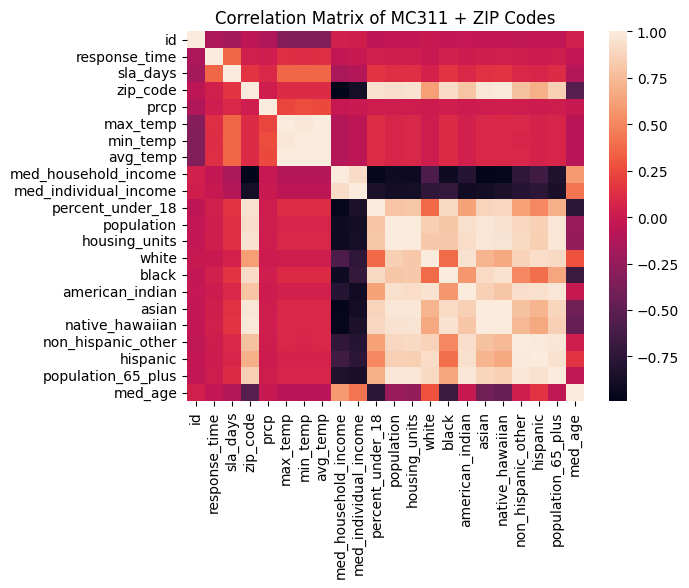

In [46]:
numeric_cols = merged.select_dtypes(include='number')
corr = numeric_cols.corr()

sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix of MC311 + ZIP Codes")
plt.show()

No strong correlations that isn't already self-explanatory



---



##**Analyzing if city impacts SLA compliance**

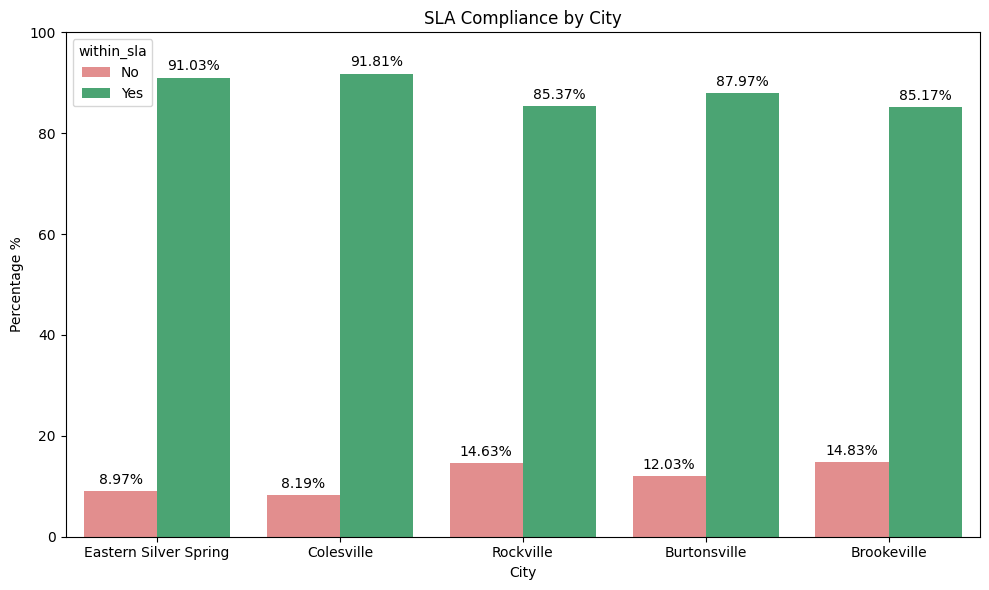

In [47]:
# Count SLA status per city
sla_status_counts = mc311.groupby(['city_name', 'within_sla']).size().reset_index(name='count')

# Calculate total requests per city
sla_status_counts['city_total'] = sla_status_counts.groupby('city_name')['count'].transform('sum')

# Percentage
sla_status_counts['percentage'] = (sla_status_counts['count'] / sla_status_counts['city_total']) * 100

# Graph
plt.figure(figsize=(10, 6))
plot = sns.barplot(data=sla_status_counts,
                 x='city_name',
                 y='percentage',
                   hue='within_sla',
                   palette={'Yes': 'mediumseagreen',
                            'No': 'lightcoral'},
                   order=mc311['city_name'].value_counts().index)
plt.title('SLA Compliance by City')
plt.xlabel('City')
plt.ylabel('Percentage %')
plt.ylim(0, 100)

# Labels
for container in plot.containers:
    plot.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

No



---



##**Over Time Analyses**

In [48]:
daily_counts = mc311.groupby('date').size().reset_index(name='count')

fig = px.line(daily_counts, x='date', y='count', title="Requests Over Time")
fig.show()

Peaks in January for both 2025 and 2026, major peak in 2026 definitely due to snowstorm. Other months show gradual highs and lows but nothing major,

###**Exploring more in depth on the patterns by focusing on service area**

In [49]:
requests_by_area_over_time = mc311.groupby(['date', 'area']).size().reset_index(name='count')

fig = px.line(requests_by_area_over_time, x='date', y='count', color='area',
              title='Requests Over Time by Service Area')
fig.update_layout(xaxis_title='Date', yaxis_title='Number of Requests')
fig.show()

The peaks in both Januarys were mainly highway services requests.

###**Exploring more in depth by looking at the high peak for highway services in 2026**

In [50]:
highway_services = mc311[mc311['area'] == 'Highway Services']

# Top topics for Highway Services
highway_topics = highway_services['area_topic'].value_counts().head(10).index.tolist()
highway_services_topics = highway_services[highway_services['area_topic'].isin(highway_topics)]

# Get counts over time
topic_over_time = highway_services_topics.groupby(['date', 'area_topic']).size().reset_index(name='count')
topic_over_time['date'] = pd.to_datetime(topic_over_time['date'])

# Filter for data in 2026
df_2026_topic = topic_over_time[topic_over_time['date'].dt.year == 2026]

# Plot
fig = px.line(df_2026_topic,
              x='date',
              y='count',
              color='area_topic',
              title='Top Highway Services Requests in 2026')
fig.update_layout(xaxis_title='Date',
                  yaxis_title='Number of Requests')
fig.show()

The peak is specifically due to reporting an unplowed/missed street, the other smaller peakers are asking about snow removal status, snow plow blocking the ways, and other snow related calls.

###**Changing the focus to patterns by city over time**

In [51]:
# Consistent coloring for cities
all_cities = merged['city_name'].unique()
colors = px.colors.qualitative.Dark24
color_city = {}

for i in range(len(all_cities)):
    city = all_cities[i]
    color_city[city] = colors[i]

In [52]:
city_over_time = mc311.groupby(['date', 'city_name']).size().reset_index(name='count')

fig = px.line(city_over_time,
              x='date',
              y='count',
              color='city_name',
              title='Requests Over Time by City',
              color_discrete_map=color_city)
fig.update_layout(xaxis_title='Date',
                  yaxis_title='Number of Requests')
fig.show()

In [53]:
# Count requests by date and city, keep to 2026 only
city_over_time = merged.groupby(['date', 'city_name']).size().reset_index(name='count')
city_over_time['date'] = pd.to_datetime(city_over_time['date'])
city_over_time = city_over_time[city_over_time['date'].dt.year == 2026]

fig = px.line(city_over_time,
              x='date',
              y='count',
              color='city_name',
              title='Requests Over Time by City (2026)',
              color_discrete_map=color_city)
fig.update_layout(xaxis_title='Date',
                  yaxis_title='Number of Requests')
fig.show()

Rockville called in the most during that peak in January.

## **Requests Over Time by City for Each Season**

In [54]:
# Month to season
season_map = { 12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
               6: 'Summer', 7: 'Summer', 8: 'Summer',
               9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}

merged['date'] = pd.to_datetime(merged['date'])
merged['season'] = merged['date'].dt.month.map(season_map)

# Filter data for 2025 only to avoid gaps due to insufficient 2026 data
merged_2025 = merged[merged['date'].dt.year == 2025]
requests_by_date_city = merged_2025.groupby(['season', 'date', 'city_name']).size().reset_index(name='count')
seasons_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# Loop to create graph for each season
for season in seasons_order:
    seasons = requests_by_date_city[requests_by_date_city['season'] == season]

    fig = px.line(seasons,
                  x='date',
                  y='count',
                  color='city_name',
                  title=f'Requests Over Time by City ({season}, 2025)',
                  labels={'count': 'Number of Requests',
                          'date': 'Date',
                          'city_name': 'City'},
                  color_discrete_map=color_city)

    fig.show()

Most requests in Winter time, specifically January. Summer also has an influx of requests.

## **Requests Over Time by Service Topic for Each City**

In [55]:
# Filter to 2025 only since I explored 2026 above
mc311_2025 = merged[merged['date'].dt.year == 2025]

# Create a color map for all unique area_topics so they're the same color in each graph
all_topics = mc311_2025['area_topic'].dropna().unique()
colors = px.colors.qualitative.Dark24
color_topic = {}

for i in range(len(all_topics)):
    topic = all_topics[i]
    color = colors[i % len(colors)]
    color_topic[topic] = color


# Create graphs for request volume trends over time for each city
for city in all_cities:
    city_data = mc311_2025[mc311_2025['city_name'] == city]
    top_topics = city_data['area_topic'].value_counts().head(10).index
    city_topic_time = (city_data[city_data['area_topic'].isin(top_topics)].groupby(['date', 'area_topic']).size().reset_index(name='count'))

    fig = px.line(city_topic_time,
                  x='date',
                  y='count',
                  color='area_topic',
                  title=f'Requests Over Time in {city}, Colored by Top Area Topics (2025)',
                  labels={'count': 'Number of Requests',
                          'date': 'Date',
                          'area_topic': 'Area Topic'},
                  color_discrete_map=color_topic)
    fig.show()

Brookeville has very little data so its lines are all over the place. The other cities show a prominent spike during the 2026 snowstorm for the "report unplowed or missed street".